# Assignment 8: Pandas Groupby with Hurricane Data #

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})

In [17]:
print("Total rows:", len(df))
print("North Atlantic hurricanes:", df[df['BASIN'] == 'NA']['SID'].nunique())

Total rows: 716165
North Atlantic hurricanes: 2344


## 1) 

In [18]:
print("Unique Basins:", df['BASIN'].unique())
print("Unique Subbasins:", df['SUBBASIN'].unique())
print("Unique Natures:", df['NATURE'].unique())

Unique Basins: ['NI' 'SI' 'NA' 'EP' 'WP' 'SP' 'SA']
Unique Subbasins: ['BB' 'AS' 'MM' 'GM' 'NA' 'CS' 'WA' 'EA' 'CP']
Unique Natures: ['NR' 'TS' 'ET' 'SS' 'MX' 'DS']


## 2) 

In [19]:
df.rename(columns={'WMO_WIND': 'WIND', 'WMO_PRES': 'PRES'}, inplace=True)

## 3) 

In [20]:
df.nlargest(10, 'WIND')

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
666140,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
666144,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
178210,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
178211,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3,-82.8,160.0,882.0


## 4) 

In [21]:
top_10_hurricanes = df.groupby('SID')['WIND'].max().nlargest(10)
print(top_10_hurricanes)

SID
2015293N13266    185.0
1980214N11330    165.0
1935241N23291    160.0
1988253N12306    160.0
1997253N12255    160.0
2005289N18282    160.0
2019236N10314    160.0
1998295N12284    155.0
2005261N21290    155.0
2009288N07267    155.0
Name: WIND, dtype: float64


## 5) 

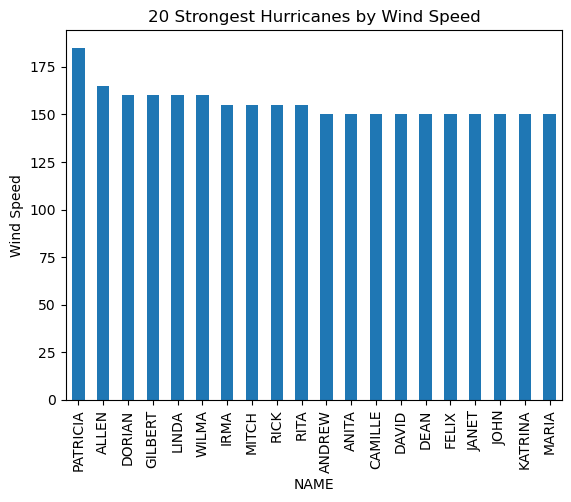

In [22]:
df.groupby('NAME')['WIND'].max().nlargest(20).plot(kind='bar', title='20 Strongest Hurricanes by Wind Speed', ylabel='Wind Speed')
plt.show()

## 6)

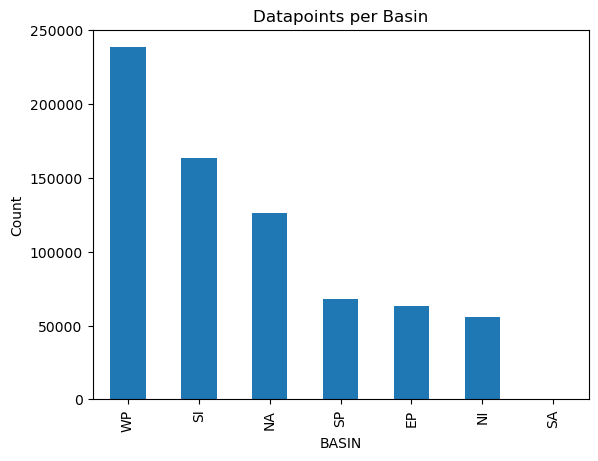

In [23]:
df['BASIN'].value_counts().plot(kind='bar', title='Datapoints per Basin', ylabel='Count')
plt.show()

## 7) 

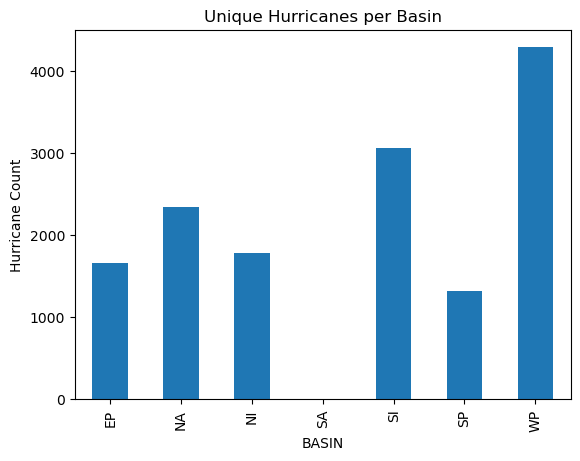

In [24]:
df.groupby('BASIN')['SID'].nunique().plot(kind='bar', title='Unique Hurricanes per Basin', ylabel='Hurricane Count')
plt.show()

## 8) 

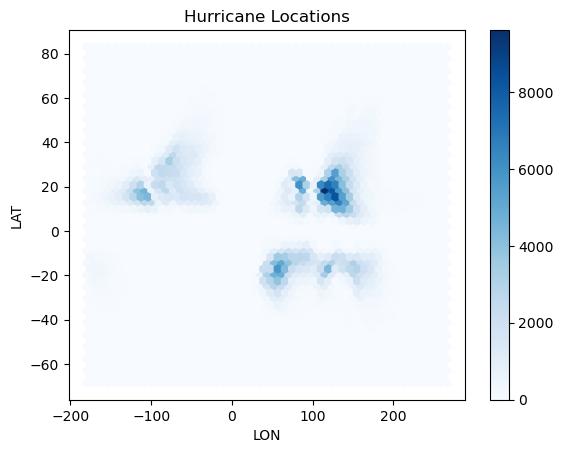

In [25]:
df.plot.hexbin(x='LON', y='LAT', gridsize=50, cmap='Blues', title='Hurricane Locations')
plt.show()

## 9) 

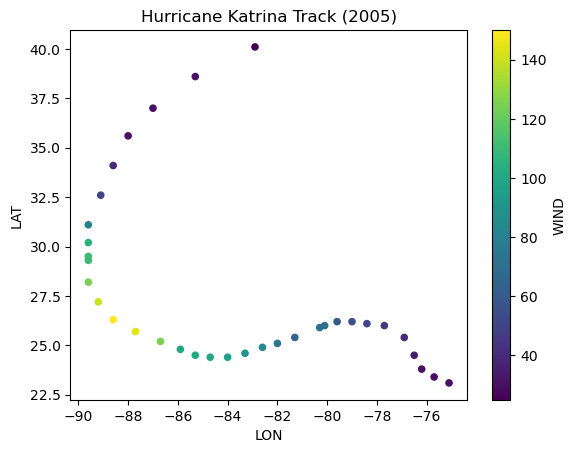

In [26]:
# Find SID for Katrina 2005
katrina_sid = df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)]['SID'].iloc[0]

# Get Katrina data
katrina_df = df[df['SID'] == katrina_sid]

# Plot
katrina_df.plot.scatter(x='LON', y='LAT', c='WIND', colormap='viridis', title='Hurricane Katrina Track (2005)')
plt.show()

## 10) 

In [27]:
df.set_index('ISO_TIME', inplace=True)

## 11) 

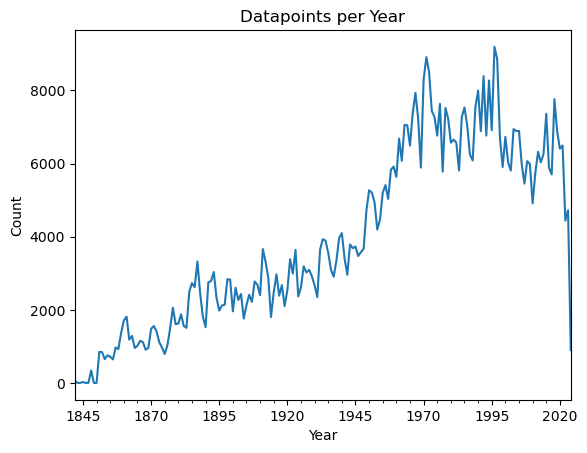

In [29]:
df.resample('YE').size().plot(title='Datapoints per Year', ylabel='Count', xlabel='Year')
plt.show()

## There are spikes in 1970, 1995 and a sudden drop in 2020. 